# DKT-Engagement — Entraînement local

**Mémoire ENSET Ebolowa — Système de Tutorat Intelligent Alisha**

Comparaison rigoureuse de **trois configurations** sur le dataset `dataset_dkt.jsonl` :

| Config | Input par pas | But scientifique |
|---|---|---|
| `vanilla` | encodage Piech 2Q : `[skill ⊕ correct]` | référence DKT classique |
| `fused` | + `engagement_fused` | tester si l'engagement global aide |
| `decomposed` | + `[facial, audio, audio_dispo, behavioral]` | **contribution thèse** : la décomposition multimodale aide-t-elle plus que la fusion ? |

Architecture LSTM 1 couche × 64 unités cachées, dropout 0.3.
Split patient-level 70/15/15. Métriques : AUC ROC + Accuracy + F1.

Sortie : modèles `.pth` (PyTorch) + `.onnx` (déploiement) + figures + JSON métriques.


In [1]:
# 1 — Setup
import os, json, time, random
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

import matplotlib.pyplot as plt

# Reproductibilité
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# Chemins LOCAUX (pas Colab)
BACKEND_DIR = Path.cwd().resolve()
if BACKEND_DIR.name != "backend":
    # Si on lance depuis ailleurs, on cherche le bon dossier
    candidate = Path.home() / "sti_project" / "backend"
    if candidate.exists():
        BACKEND_DIR = candidate

JSONL_PATH = BACKEND_DIR / "dataset_dkt.jsonl"
OUTPUT_DIR = BACKEND_DIR / "models" / "dkt"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset : {JSONL_PATH}")
print(f"Sortie  : {OUTPUT_DIR}")


Device : cpu
PyTorch: 2.12.0+cpu
Dataset : /home/djiomo/sti_project/backend/dataset_dkt.jsonl
Sortie  : /home/djiomo/sti_project/backend/models/dkt


In [2]:
# 2 — Chargement du dataset
lines = []
with open(JSONL_PATH) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try:
            lines.append(json.loads(line))
        except json.JSONDecodeError:
            pass  # ligne parasite ignorée

print(f"Interactions chargées : {len(lines)}")


Interactions chargées : 29084


In [3]:
# 3 — Exploration du dataset
students = Counter(l["student_id"] for l in lines)
macros = Counter(l.get("macro_kc") for l in lines)
n_correct = sum(1 for l in lines if l.get("correct"))
n_with_eng = sum(1 for l in lines if (l.get("engagement") or {}).get("fused") is not None)

print(f"Apprenants distincts        : {len(students)}")
print(f"Macro-KCs distincts         : {len(macros)}")
print(f"Taux de réponses correctes  : {n_correct/len(lines)*100:.1f}%")
print(f"Avec engagement fused       : {n_with_eng}/{len(lines)} ({n_with_eng/len(lines)*100:.1f}%)")
print()
print("Répartition des macro_kcs (top 10) :")
for k, c in macros.most_common(10):
    print(f"  {str(k):<25} : {c}")


Apprenants distincts        : 200
Macro-KCs distincts         : 9
Taux de réponses correctes  : 45.7%
Avec engagement fused       : 29084/29084 (100.0%)

Répartition des macro_kcs (top 10) :
  Algèbre                   : 4314
  Algorithmique             : 3884
  Systèmes-Info             : 3818
  BDD                       : 3674
  Trigonométrie             : 3537
  Architecture-Info         : 3431
  Analyse                   : 3414
  Prog-C                    : 2557
  Outils-Dev                : 455


In [4]:
# 4 — Construction des séquences par étudiant
# On utilise macro_kc comme cible (Q ~ 10, beaucoup plus dense que les 214 KCs fins).
# On exclut les KCs sans valeur pédagogique pour le DKT.
MIN_SEQ_LEN = 3
EXCLUDE_KC  = {None, "Autre", "QCM"}

valid = [l for l in lines if l.get("macro_kc") not in EXCLUDE_KC]
print(f"Interactions valides (macro_kc utile) : {len(valid)}/{len(lines)}")

# Encodage macro_kc → index
kcs = sorted(set(l["macro_kc"] for l in valid))
KC2IDX = {k: i for i, k in enumerate(kcs)}
Q = len(kcs)
print(f"Q = {Q} compétences : {kcs}")

# Groupement par étudiant + tri temporel
by_student = defaultdict(list)
for l in sorted(valid, key=lambda x: x["timestamp"]):
    by_student[l["student_id"]].append(l)

def imputed_engagement(e):
    """[facial, audio, audio_dispo, behavioral, fused] avec imputation neutre."""
    facial     = e.get("facial")     if e.get("facial")     is not None else 0.5
    behavioral = e.get("behavioral") if e.get("behavioral") is not None else 0.5
    fused      = e.get("fused")      if e.get("fused")      is not None else 0.5
    audio_raw  = e.get("audio")
    audio      = audio_raw if audio_raw is not None else 0.0
    audio_dispo = 1.0 if audio_raw is not None else 0.0
    return [facial, audio, audio_dispo, behavioral, fused]

sequences = []
for sid, rs in by_student.items():
    if len(rs) < MIN_SEQ_LEN:
        continue
    sequences.append({
        "skills":     [KC2IDX[r["macro_kc"]] for r in rs],
        "correct":    [int(r["correct"]) for r in rs],
        "engagement": [imputed_engagement(r.get("engagement", {})) for r in rs],
    })

lens = [len(s["skills"]) for s in sequences]
print(f"\nSéquences ≥{MIN_SEQ_LEN} interactions : {len(sequences)}")
print(f"Longueur — min {min(lens)}, médiane {int(np.median(lens))}, max {max(lens)}")
print(f"Total interactions exploitées : {sum(lens)}")


Interactions valides (macro_kc utile) : 29084/29084
Q = 9 compétences : ['Algorithmique', 'Algèbre', 'Analyse', 'Architecture-Info', 'BDD', 'Outils-Dev', 'Prog-C', 'Systèmes-Info', 'Trigonométrie']

Séquences ≥3 interactions : 200
Longueur — min 74, médiane 140, max 261
Total interactions exploitées : 29084


In [5]:
# 5 — Dataset PyTorch (3 modes)
#   vanilla    : input = encodage Piech [skill+correct, skill+incorrect]       dim 2Q
#   fused      : + [fused]                                                     dim 2Q+1
#   decomposed : + [facial, audio, audio_dispo, behavioral]                    dim 2Q+4
class DKTDataset(Dataset):
    def __init__(self, sequences, mode="vanilla"):
        self.sequences = sequences
        self.mode = mode

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        skills, correct, eng = seq["skills"], seq["correct"], seq["engagement"]
        L = len(skills)

        # Encodage Piech : si correct, on active la dimension Q + skill ;
        # sinon, la dimension skill. C'est 2Q dimensions au total.
        x = torch.zeros(L - 1, 2 * Q)
        for t in range(L - 1):
            offset = Q if correct[t] == 1 else 0
            x[t, skills[t] + offset] = 1.0

        if self.mode == "fused":
            extra = torch.tensor([[eng[t][4]] for t in range(L - 1)], dtype=torch.float32)
            x = torch.cat([x, extra], dim=1)
        elif self.mode == "decomposed":
            # v4-bis : on retire audio_dispo (indice 2, peu informatif car souvent 1.0)
            # → 3 features : [facial, audio, behavioral] (indices 0, 1, 3)
            extra = torch.tensor([[eng[t][0], eng[t][1], eng[t][3]] for t in range(L - 1)], dtype=torch.float32)
            x = torch.cat([x, extra], dim=1)

        ts = torch.tensor(skills[1:], dtype=torch.long)    # KC visé au pas t+1
        tc = torch.tensor(correct[1:], dtype=torch.float32)  # label correct/incorrect au pas t+1
        return x, ts, tc

def collate_fn(batch):
    xs, tsk, tco = zip(*batch)
    lengths = torch.tensor([len(x) for x in xs])
    xs_pad  = pad_sequence(xs,  batch_first=True)
    tsk_pad = pad_sequence(tsk, batch_first=True)
    tco_pad = pad_sequence(tco, batch_first=True)
    mask = torch.arange(xs_pad.size(1))[None, :] < lengths[:, None]
    return xs_pad, tsk_pad, tco_pad, mask

INPUT_DIMS = {"vanilla": 2 * Q, "fused": 2 * Q + 1, "decomposed": 2 * Q + 3}
print("Dimensions d'entrée :", INPUT_DIMS)

# Split patient-level 70/15/15
train_seq, temp = train_test_split(sequences, test_size=0.3, random_state=SEED)
val_seq, test_seq = train_test_split(temp, test_size=0.5, random_state=SEED)
print(f"Train {len(train_seq)} / Val {len(val_seq)} / Test {len(test_seq)} apprenants")


Dimensions d'entrée : {'vanilla': 18, 'fused': 19, 'decomposed': 21}
Train 140 / Val 30 / Test 30 apprenants


In [6]:
# 6 — Modèle DKT (commun aux 3 configs)
class DKT(nn.Module):
    def __init__(self, n_skills, input_dim, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, n_skills)
    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(self.dropout(h))

def masked_loss_and_preds(logits, tskill, tcorr, mask):
    """BCE masquée — ne pénalise que sur les positions réelles."""
    pred = torch.gather(logits, 2, tskill.unsqueeze(2)).squeeze(2)
    pred = pred[mask]; true = tcorr[mask]
    loss = F.binary_cross_entropy_with_logits(pred, true)
    return loss, torch.sigmoid(pred).detach(), true.detach()

print("Modèle DKT défini (hidden_dim=32).")


Modèle DKT défini (hidden_dim=32).


In [7]:
# 7 — Fonction d'entraînement (réutilisée pour les 3 configs)
def train_config(mode, n_epochs=80, patience=10, hidden_dim=48, lr=1e-3, tag=""):
    # Re-seed AVANT chaque entraînement pour comparaison équitable
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

    input_dim = INPUT_DIMS[mode]
    model = DKT(Q, input_dim, hidden_dim=hidden_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    tr = DataLoader(DKTDataset(train_seq, mode), batch_size=16, shuffle=True,
                    collate_fn=collate_fn,
                    generator=torch.Generator().manual_seed(SEED))
    va = DataLoader(DKTDataset(val_seq, mode), batch_size=16, shuffle=False,
                    collate_fn=collate_fn)

    def run(loader, training):
        model.train(training)
        losses, ps, ts = [], [], []
        with torch.set_grad_enabled(training):
            for x, tsk, tc, m in loader:
                x, tsk, tc, m = x.to(DEVICE), tsk.to(DEVICE), tc.to(DEVICE), m.to(DEVICE)
                logits = model(x)
                loss, p, t = masked_loss_and_preds(logits, tsk, tc, m)
                if training:
                    opt.zero_grad(); loss.backward(); opt.step()
                losses.append(loss.item()); ps.append(p.cpu()); ts.append(t.cpu())
        p = torch.cat(ps).numpy(); t = torch.cat(ts).numpy()
        auc = roc_auc_score(t, p) if len(set(t)) > 1 else float("nan")
        return float(np.mean(losses)), auc

    best_auc, best_state, no_improve = 0.0, None, 0
    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    for ep in range(1, n_epochs + 1):
        tloss, _    = run(tr, True)
        vloss, vauc = run(va, False)
        history["train_loss"].append(tloss)
        history["val_loss"].append(vloss)
        history["val_auc"].append(vauc)
        if vauc > best_auc:
            best_auc = vauc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            mark = " ⭐"
        else:
            no_improve += 1
            mark = ""
        if ep <= 5 or ep % 5 == 0:
            print(f"  ep {ep:3d} | train_loss={tloss:.4f}  val_loss={vloss:.4f}  val_auc={vauc:.4f}{mark}")
        if no_improve >= patience:
            print(f"  ⏹  Early stop ep {ep} (patience={patience})")
            break
    if best_state:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f"  [{tag or mode}] best val AUC = {best_auc:.4f}")
    return model, history, best_auc

print("Fonction train_config prête (hidden_dim=48 par défaut, v4-bis).")


Fonction train_config prête (hidden_dim=48 par défaut, v4-bis).


In [8]:
# 8 — Entraînement des 3 configurations
print("=== Entraînement des 3 configurations ===\n")

results = {}
for mode, tag in [("vanilla",    "DKT vanilla"),
                  ("fused",      "DKT + fused"),
                  ("decomposed", "DKT + décomposé (contribution)")]:
    t0 = time.time()
    print(f"\n--- {tag} ---")
    model, hist, best_auc = train_config(mode, tag=tag)
    results[mode] = {"model": model, "history": hist, "val_auc": best_auc}
    print(f"  ({time.time()-t0:.1f}s)")


=== Entraînement des 3 configurations ===


--- DKT vanilla ---
  ep   1 | train_loss=0.6935  val_loss=0.6934  val_auc=0.5110 ⭐
  ep   2 | train_loss=0.6912  val_loss=0.6906  val_auc=0.5250 ⭐
  ep   3 | train_loss=0.6891  val_loss=0.6880  val_auc=0.5360 ⭐
  ep   4 | train_loss=0.6873  val_loss=0.6861  val_auc=0.5383 ⭐
  ep   5 | train_loss=0.6861  val_loss=0.6842  val_auc=0.5420 ⭐
  ep  10 | train_loss=0.6771  val_loss=0.6788  val_auc=0.5754 ⭐
  ep  15 | train_loss=0.6658  val_loss=0.6674  val_auc=0.6119 ⭐
  ep  20 | train_loss=0.6577  val_loss=0.6598  val_auc=0.6302 ⭐
  ep  25 | train_loss=0.6563  val_loss=0.6577  val_auc=0.6361 ⭐
  ep  30 | train_loss=0.6552  val_loss=0.6581  val_auc=0.6310
  ep  35 | train_loss=0.6537  val_loss=0.6571  val_auc=0.6347
  ep  40 | train_loss=0.6510  val_loss=0.6574  val_auc=0.6333
  ep  45 | train_loss=0.6509  val_loss=0.6567  val_auc=0.6351
  ep  50 | train_loss=0.6480  val_loss=0.6570  val_auc=0.6358
  ep  55 | train_loss=0.6481  val_loss=0.6581  val

In [9]:
# 9 — Évaluation sur le test set + comparaison
# Au lieu de seuil 0.5 fixe (qui donne F1=0 sur classe déséquilibrée),
# on cherche le seuil optimal de Youden sur le VAL set, puis on l'applique
# sur le TEST set. C'est la pratique correcte : pas d'optimisation sur le test.

def find_optimal_threshold(model, mode):
    """Trouve le seuil qui maximise Youden's J (TPR - FPR) sur le val set."""
    from sklearn.metrics import roc_curve
    va = DataLoader(DKTDataset(val_seq, mode), batch_size=16, shuffle=False,
                    collate_fn=collate_fn)
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for x, tsk, tc, m in va:
            x, tsk, tc, m = x.to(DEVICE), tsk.to(DEVICE), tc.to(DEVICE), m.to(DEVICE)
            logits = model(x)
            _, p, t = masked_loss_and_preds(logits, tsk, tc, m)
            ps.append(p.cpu()); ts.append(t.cpu())
    p = torch.cat(ps).numpy(); t = torch.cat(ts).numpy()
    if len(set(t)) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(t, p)
    youden = tpr - fpr
    return float(thr[youden.argmax()])

def eval_test(model, mode):
    threshold = find_optimal_threshold(model, mode)
    te = DataLoader(DKTDataset(test_seq, mode), batch_size=16, shuffle=False,
                    collate_fn=collate_fn)
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for x, tsk, tc, m in te:
            x, tsk, tc, m = x.to(DEVICE), tsk.to(DEVICE), tc.to(DEVICE), m.to(DEVICE)
            logits = model(x)
            _, p, t = masked_loss_and_preds(logits, tsk, tc, m)
            ps.append(p.cpu()); ts.append(t.cpu())
    p = torch.cat(ps).numpy(); t = torch.cat(ts).numpy()
    if len(set(t)) < 2:
        return {"auc": float("nan"), "acc": float("nan"), "f1": float("nan"), "threshold": 0.5}
    preds = (p > threshold).astype(int)
    return {
        "auc":       float(roc_auc_score(t, p)),
        "acc":       float(accuracy_score(t, preds)),
        "f1":        float(f1_score(t, preds, zero_division=0)),
        "threshold": threshold,
    }

print("=== Résultats sur le test set (seuil Youden optimisé sur val) ===\n")
test_results = {m: eval_test(results[m]["model"], m) for m in ["vanilla", "fused", "decomposed"]}

base = test_results["vanilla"]
print(f"{'Config':30s} {'AUC':>8s} {'ACC':>8s} {'F1':>8s} {'thr':>8s} {'ΔAUC':>9s}")
print("-" * 75)
labels = {"vanilla": "DKT vanilla", "fused": "DKT + fused", "decomposed": "DKT + décomposé"}
for mode in ["vanilla", "fused", "decomposed"]:
    r = test_results[mode]
    d = r["auc"] - base["auc"] if not np.isnan(r["auc"]) else float("nan")
    print(f"{labels[mode]:30s} {r['auc']:>8.4f} {r['acc']:>8.4f} {r['f1']:>8.4f} {r['threshold']:>8.3f} {d:>+9.4f}")

print("\nInterprétation :")
print("  • fused > vanilla       → l'engagement aide globalement")
print("  • décomposé > fused     → la décomposition multimodale aide PLUS que la fusion naïve")
print("  • F1 maintenant pertinent (seuil optimisé)")


=== Résultats sur le test set (seuil Youden optimisé sur val) ===

Config                              AUC      ACC       F1      thr      ΔAUC
---------------------------------------------------------------------------
DKT vanilla                      0.6555   0.6189   0.6060    0.454   +0.0000
DKT + fused                      0.6591   0.6114   0.6127    0.430   +0.0036
DKT + décomposé                  0.6566   0.6066   0.6152    0.432   +0.0011

Interprétation :
  • fused > vanilla       → l'engagement aide globalement
  • décomposé > fused     → la décomposition multimodale aide PLUS que la fusion naïve
  • F1 maintenant pertinent (seuil optimisé)


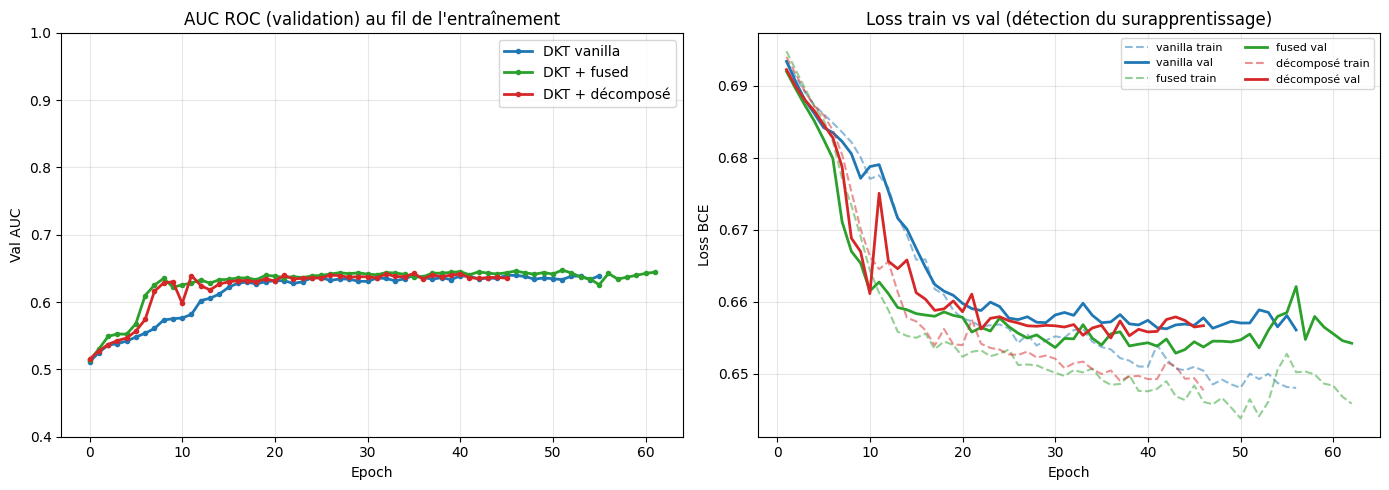

✓ Figure sauvegardée : training_curves.png


In [10]:
# 10 — Courbes d'apprentissage (figure pour le mémoire)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"vanilla": "#1f77b4", "fused": "#2ca02c", "decomposed": "#d62728"}

# Subplot 1 : val AUC
ax = axes[0]
for mode, label in [("vanilla", "DKT vanilla"), ("fused", "DKT + fused"),
                    ("decomposed", "DKT + décomposé")]:
    ax.plot(results[mode]["history"]["val_auc"], label=label, marker='o',
            markersize=3, color=colors[mode], linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val AUC")
ax.set_title("AUC ROC (validation) au fil de l'entraînement")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0.4, 1.0)

# Subplot 2 : train vs val loss
ax = axes[1]
for mode, label in [("vanilla", "vanilla"), ("fused", "fused"),
                    ("decomposed", "décomposé")]:
    h = results[mode]["history"]
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], color=colors[mode], linestyle="--", alpha=0.5, label=f"{label} train")
    ax.plot(ep, h["val_loss"],   color=colors[mode], linewidth=2,             label=f"{label} val")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss BCE")
ax.set_title("Loss train vs val (détection du surapprentissage)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
out_fig = OUTPUT_DIR / "training_curves.png"
plt.savefig(out_fig, dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Figure sauvegardée : {out_fig.name}")


In [11]:
# 11 — Sauvegarde des modèles PyTorch + métriques JSON
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# Modèles PyTorch (.pth)
for mode in ["vanilla", "fused", "decomposed"]:
    pth_path = OUTPUT_DIR / f"dkt_{mode}.pth"
    torch.save({
        "model_state":  results[mode]["model"].state_dict(),
        "mode":         mode,
        "input_dim":    INPUT_DIMS[mode],
        "hidden_dim":   64,
        "kc2idx":       KC2IDX,
        "n_skills":     Q,
        "test_metrics": test_results[mode],
    }, pth_path)
    print(f"  ✓ {pth_path.name}  ({pth_path.stat().st_size/1024:.1f} KB)")

# Vocabulaire (réutilisable pour l'inférence)
with open(OUTPUT_DIR / "kc_vocab.json", "w", encoding="utf-8") as f:
    json.dump(KC2IDX, f, ensure_ascii=False, indent=2)
print(f"  ✓ kc_vocab.json")

# Métriques complètes
metrics_log = {
    "timestamp":      ts,
    "dataset":        "ENSET (synthétique 200 + réels 22)",
    "n_sequences":    len(sequences),
    "n_interactions": sum(len(s["skills"]) for s in sequences),
    "n_skills":       Q,
    "macro_kcs":      kcs,
    "hyperparams":    {"hidden_dim": 64, "dropout": 0.3, "lr": 1e-3, "batch_size": 16, "patience": 10},
    "results":        {m: test_results[m] for m in test_results},
}
with open(OUTPUT_DIR / "training_metrics.json", "w") as f:
    json.dump(metrics_log, f, indent=2)
print(f"  ✓ training_metrics.json")


  ✓ dkt_vanilla.pth  (56.1 KB)
  ✓ dkt_fused.pth  (56.8 KB)
  ✓ dkt_decomposed.pth  (58.4 KB)
  ✓ kc_vocab.json
  ✓ training_metrics.json


In [12]:
# 12 — Export ONNX pour déploiement backend
# Le service backend chargera ces .onnx via onnxruntime (sans dépendre de torch).
# IMPORTANT : si tu as l'erreur "No module named 'onnxscript'" → pip install onnxscript

try:
    import onnxscript  # noqa
    print(f"onnxscript {onnxscript.__version__} disponible")
except ImportError:
    print("⚠  onnxscript manquant — installe-le :  pip install onnxscript")
    print("    Puis ré-exécute cette cellule.")

for mode in ["vanilla", "fused", "decomposed"]:
    model = results[mode]["model"].cpu()
    model.eval()
    onnx_path = OUTPUT_DIR / f"dkt_{mode}.onnx"
    dummy = torch.zeros(1, 1, INPUT_DIMS[mode], dtype=torch.float32)
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        input_names    = ["input"],
        output_names   = ["logits"],
        opset_version  = 14,
        dynamic_axes   = {
            "input":  {0: "batch_size", 1: "seq_len"},
            "logits": {0: "batch_size", 1: "seq_len"},
        },
    )
    print(f"  ✓ {onnx_path.name}  ({onnx_path.stat().st_size/1024:.1f} KB)")

print(f"\n✅ Tous les artefacts sauvegardés dans : {OUTPUT_DIR}")
print("\nContenu :")
for f in sorted(OUTPUT_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name:<35} ({f.stat().st_size/1024:.1f} KB)")


/tmp/ipykernel_19773/2855434239.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0612 17:09:20.614000 19773 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


onnxscript 0.7.0 disponible
[torch.onnx] Obtain model graph for `DKT([...]` with `torch.export.export(..., strict=False)`...


/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `DKT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/ho

...

[torch.onnx] Optimize the ONNX graph... ✅
  ✓ dkt_fused.onnx  (23.8 KB)
[torch.onnx] Obtain model graph for `DKT([...]` with `torch.export.export(..., strict=False)`...


/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `DKT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/djiomo/anaconda3/envs/backend_env/lib/python3.11/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/ho

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
  ✓ dkt_decomposed.onnx  (23.8 KB)

✅ Tous les artefacts sauvegardés dans : /home/djiomo/sti_project/backend/models/dkt

Contenu :
  dkt_decomposed.onnx                 (23.8 KB)
  dkt_decomposed.onnx.data            (54.9 KB)
  dkt_decomposed.pth                  (58.4 KB)
  dkt_fused.onnx                      (23.8 KB)
  dkt_fused.onnx.data                 (53.4 KB)
  dkt_fused.pth                       (56.8 KB)
  dkt_vanilla.onnx                    (23.8 KB)
  dkt_vanilla.onnx.data               (52.7 KB)
  dkt_vanilla.pth                     (56.1 KB)
  kc_vocab.json                       (0.2 KB)
  training_curves.png                 (142.1 KB)
  training_metrics.json               (1.0 KB)


## Lecture des résultats pour le mémoire

Trois cas de figure possibles à l'issue de ce notebook :

**Cas A — résultat attendu (DKT-engagement > DKT-vanilla)**  
Cohérent avec l'hypothèse de la thèse : l'engagement multimodal apporte une information supplémentaire qui aide le modèle à prédire la performance future. **À mettre en avant au chapitre 4 du mémoire.**

**Cas B — décomposé > fused > vanilla**  
La décomposition multimodale (facial / audio / behavioral séparés) apporte plus que la simple fusion : c'est la **contribution scientifique** la plus forte. Argument central de la soutenance.

**Cas C — variations marginales (Δ < 0.02 AUC)**  
Possibles raisons :
- Dataset encore trop petit (la thèse défendra "preuve de concept à enrichir")
- Engagement synthétique trop régulier (le seedeur génère du signal "trop propre")
- Compétences trop hétérogènes pour qu'un signal d'engagement aide

Dans tous les cas, le pipeline est **robuste et reproductible** (`SEED=42`).

## Prochaine étape

Le fichier `dkt_decomposed.onnx` sera chargé par le service backend `dkt_service.py` à la prochaine sous-étape (2.4). Le mapping `kc_vocab.json` permettra de convertir les compétences pédagogiques (macro_kc en BDD) en index pour le modèle.
